In [15]:
import matplotlib.pyplot as plt
import gymnasium as gym
import numpy as np

MAX_ITERATIONS = 100

env = gym.make("FrozenLake8x8-v1", is_slippery=False, render_mode="ansi")

state, info = env.reset()

print(env.render())

num_states = env.observation_space.n
num_actions = env.action_space.n
discount = 0.99

P = np.zeros((num_states, num_actions, num_states))
R = np.zeros((num_states, num_actions, num_states))

for state in range(num_states):
    for action in range(num_actions):
        for prob, next_state, reward, terminated in env.unwrapped.P[state][action]:
            P[state, action, next_state] += prob
            R[state, action, next_state] += reward



def plot_policy_on_frozen_lake(env, policy, title="FrozenLake policy"):
    desc = np.asarray(env.unwrapped.desc, dtype=str)
    policy_grid = np.asarray(policy).reshape(desc.shape)
    arrows = np.array(["<", "v", ">", "^"])
    colors = {
        "S": "#9be7a1",
        "F": "#dceefb",
        "H": "#3a3a3a",
        "G": "#ffd54f",
    }

    fig, ax = plt.subplots(figsize=(8, 8))
    for r in range(desc.shape[0]):
        for c in range(desc.shape[1]):
            tile = desc[r, c]
            rect = plt.Rectangle((c, desc.shape[0] - 1 - r), 1, 1, facecolor=colors[tile], edgecolor="black", linewidth=1.5)
            ax.add_patch(rect)

            if tile == "H":
                label = "H"
            elif tile == "G":
                label = "G"
            elif tile == "S":
                label = f"S{arrows[policy_grid[r, c]]}"
            else:
                label = arrows[policy_grid[r, c]]

            ax.text(c + 0.5, desc.shape[0] - 1 - r + 0.5, label, ha="center", va="center", fontsize=16, fontweight="bold", color="black")

    ax.set_xlim(0, desc.shape[1])
    ax.set_ylim(0, desc.shape[0])
    ax.set_xticks(np.arange(desc.shape[1] + 1))
    ax.set_yticks(np.arange(desc.shape[0] + 1))
    ax.grid(True, color="black", linewidth=1.0)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_aspect("equal")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

def vi(P, R, discount):

    num_states, _ , _ = P.shape
    V = np.zeros(num_states)

    theta = 1e-8

    while True:

        V_updated = np.max(np.sum(P * (R + discount * V[None, None, :]), axis=2), axis=1)

        if np.max(np.abs(V - V_updated)) < theta:
            break

        V = V_updated

    policy = np.argmax(np.sum(P * (R + discount * V[None, None, :]), axis=2), axis=1)
    
    return V, policy

def pi(P, R, discount):
    num_states, _ , _ = P.shape
    V = np.zeros(num_states)
    policy = np.zeros(num_states, dtype=int)
    
    theta = 1e-8

    while True:

        while True:
            V_updated = np.sum(P * (R + discount * V[None, None, :]), axis=2)[np.arange(num_states), policy]

            if np.max(np.abs(V - V_updated)) < theta:
                break

            V = V_updated


        policy_updated = np.argmax(np.sum(P * (R + discount * V[None, None, :]), axis=2), axis=1)
        
        if np.array_equal(policy_updated, policy):
            break

        policy = policy_updated

    return V, policy

def linear(P, R, discount):
    num_states, _, _ = P.shape
    V = np.zeros(num_states)
    policy = np.zeros(num_states, dtype=int)
    i = 1
    while True:
        V_updated = np.linalg.solve(
            np.eye(num_states) - discount * P[np.arange(num_states), policy, :], 
            np.sum(P[np.arange(num_states), policy, :] * R[np.arange(num_states), policy, :], axis=1)
        )

        V = V_updated
        
        policy_updated = np.argmax(np.sum(P * (R + discount * V[None, None, :]), axis=2), axis=1)
        
        if np.array_equal(policy_updated, policy):
            break
            
        policy = policy_updated

        i+=1
        
    return V, policy



    


SFFFFFFF
FFFFFFFF
FFFHFFFF
FFFFFHFF
FFFHFFFF
FHHFFFHF
FHFFHFHF
FFFHFFFG



In [16]:


v_vi, policy_vi = vi(P, R, discount)

print("Value Iteration Policy:", policy_vi)
print(f"Value Iteration Value Function:\n {v_vi}")

v_pi, policy_pi = pi(P, R, discount)

print("Policy Iteration Policy:", policy_pi)
print(f"Policy Iteration Value Function:\n {v_pi}")

v_linear, policy_linear = linear(P, R, discount)

print("Linear Programming Policy:", policy_linear)
print(f"Linear Programming Value Function:\n {v_linear}")

env.close()

Value Iteration Policy: [1 1 1 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 1 0 1 2 1 1 2 2 2 2 1 0 1 1 2 2 3 0 1
 1 2 1 1 0 0 2 2 1 0 1 1 0 2 3 0 1 0 1 2 2 3 0 2 2 2 0]
Value Iteration Value Function:
 [0.87752102 0.88638487 0.89533825 0.90438208 0.91351725 0.92274469
 0.93206535 0.94148015 0.88638487 0.89533825 0.90438208 0.91351725
 0.92274469 0.93206535 0.94148015 0.95099005 0.89533825 0.90438208
 0.91351725 0.         0.93206535 0.94148015 0.95099005 0.96059601
 0.90438208 0.91351725 0.92274469 0.93206535 0.94148015 0.
 0.96059601 0.970299   0.89533825 0.90438208 0.91351725 0.
 0.95099005 0.96059601 0.970299   0.9801     0.88638487 0.
 0.         0.95099005 0.96059601 0.970299   0.         0.99
 0.89533825 0.         0.93206535 0.94148015 0.         0.9801
 0.         1.         0.90438208 0.91351725 0.92274469 0.
 0.9801     0.99       1.         0.        ]
Policy Iteration Policy: [1 1 1 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 1 0 1 2 1 1 2 2 2 2 1 0 1 1 2 2 3 0 1
 1 2 1 1 0 0 2 2 1 0 1 1 0 2 3 0 1 0 1

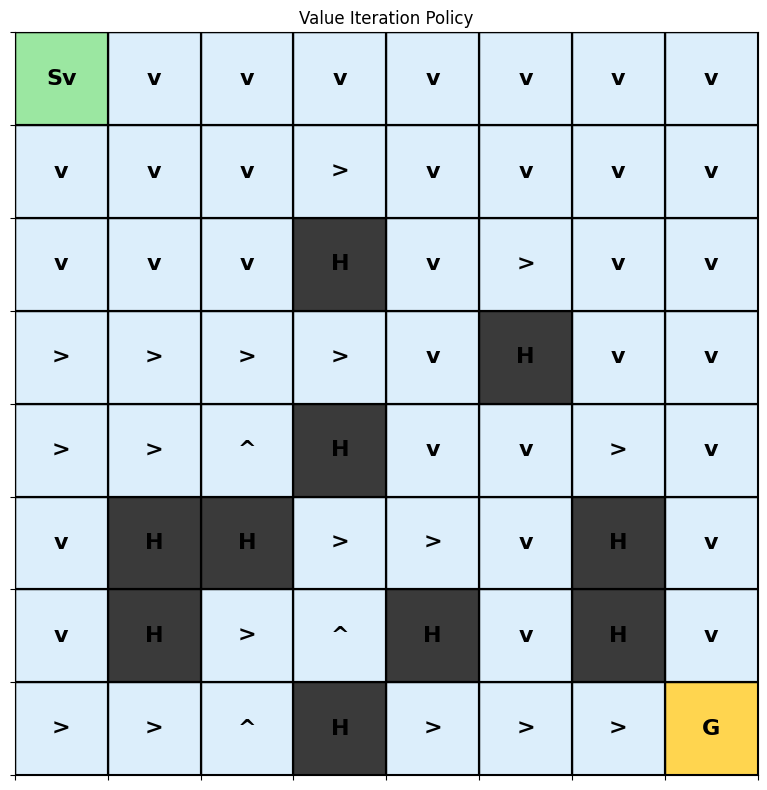

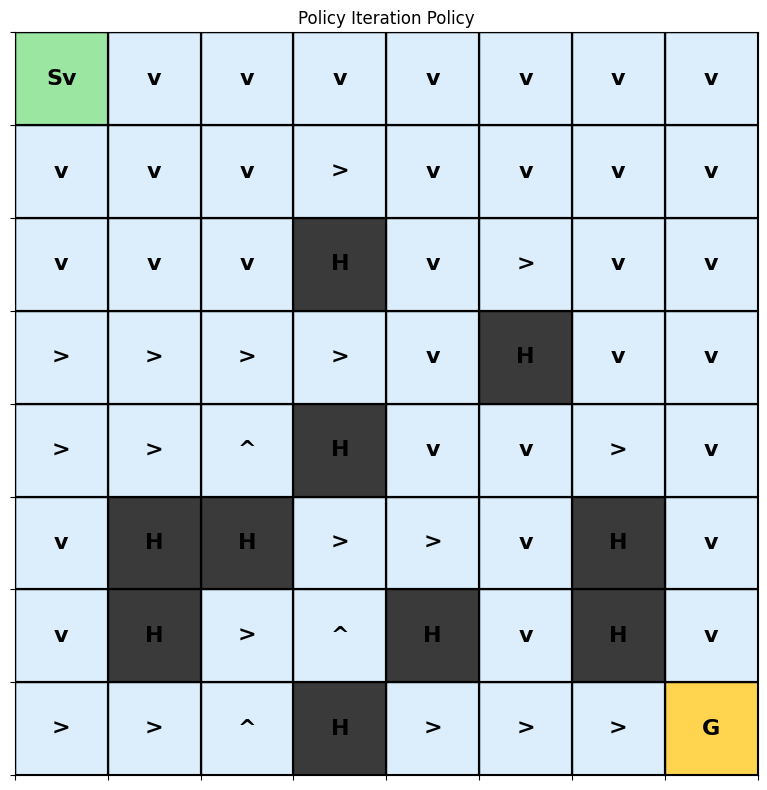

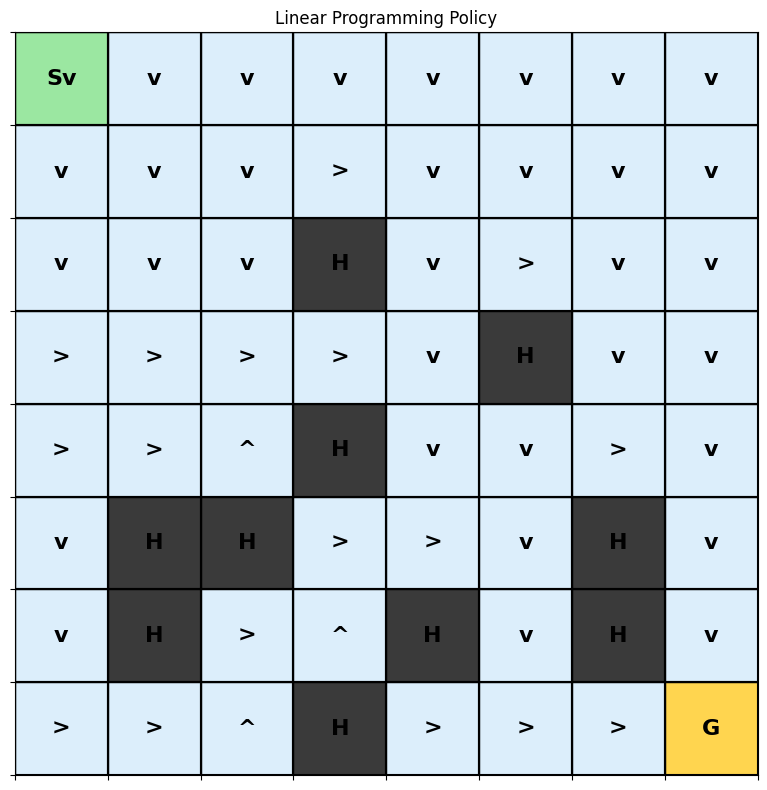

In [17]:

plot_policy_on_frozen_lake(env, policy_vi, title="Value Iteration Policy")
plot_policy_on_frozen_lake(env, policy_pi, title="Policy Iteration Policy")
plot_policy_on_frozen_lake(env, policy_linear, title="Linear Programming Policy")   
